<a href="https://colab.research.google.com/github/adoraonubogu-png/Adora_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [44]:

!pip install -q pandas matplotlib mlxtend networkx

import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx

df = pd.read_csv('bread_basket.csv')

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [45]:
print("Variables and their Data Types:")
print(df.dtypes)

Variables and their Data Types:
transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [46]:
# Generates summary statistics similar to RapidMiner
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

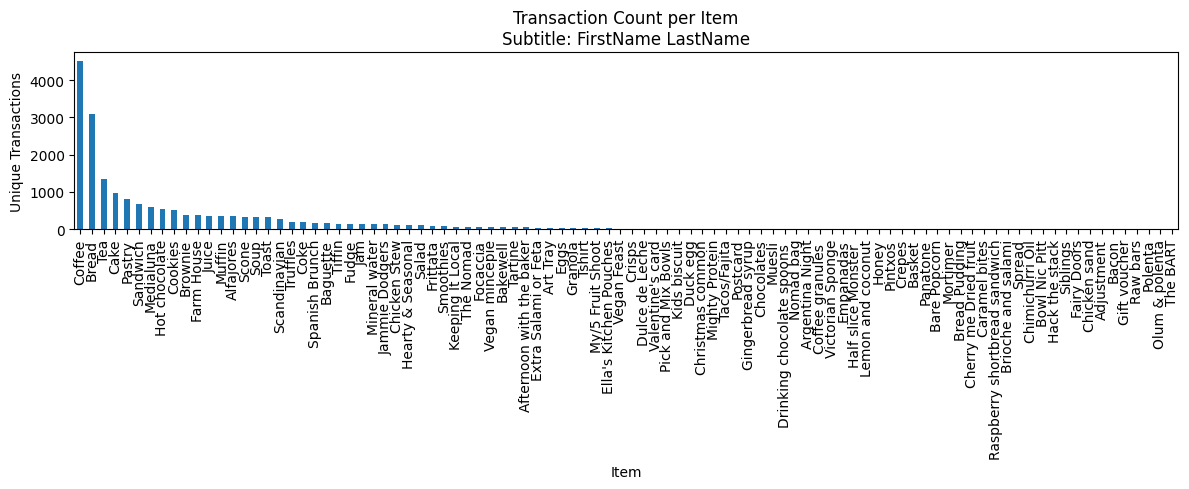

In [47]:
# c) Bar plot of transaction counts per item
subtitle = "FirstName LastName"  # <-- EDIT THIS
item_counts = (df.groupby('item')['transaction'].nunique()
                 .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [48]:
target_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
print("Transaction Counts for Specific Items:\n" + "-"*35)

for item in target_items:
    if item in df['item'].values:
        count = df[df['item'] == item]['transaction'].nunique()
        print(f"{item}: {count}")
    else:
        print(f"{item}: 0 (Not found)")

Transaction Counts for Specific Items:
-----------------------------------
Coffee: 4528
Tea: 1350
Alfajores: 344
Juice: 365
Chicken Stew: 123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [49]:
basket = pd.crosstab(df['transaction'], df['item']).astype(bool)

frequent_itemsets = fpgrowth(basket, min_support=0.005, use_colnames=True)

print("Frequent Itemsets (min_support=0.005):")
display(frequent_itemsets)

Frequent Itemsets (min_support=0.005):


,support,itemsets
0,0.327205,(Bread)
1,0.029054,(Scandinavian)
2,0.058320,(Hot chocolate)
3,0.054411,(Cookies)
4,0.015003,(Jam)
...,...,...
109,0.018067,"(Scone, Coffee)"
110,0.008347,"(Scone, Tea)"
111,0.006550,"(Coffee, Salad)"
112,0.005177,"(Coffee, Chicken Stew)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [50]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.15)

print("Association Rules (Confidence >= 15%):")
display(rules)

Association Rules (Confidence >= 15%):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
1,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
2,(Scandinavian),(Bread),0.029054,0.327205,0.006550,0.225455,0.689030,1.0,-0.002956,0.868631,-0.317322,0.018731,-0.151236,0.122737
3,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
4,(Hot chocolate),(Bread),0.058320,0.327205,0.013418,0.230072,0.703144,1.0,-0.005665,0.873841,-0.309550,0.036059,-0.144373,0.135540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
75,(Scone),(Tea),0.034548,0.142631,0.008347,0.241590,1.693816,1.0,0.003419,1.130483,0.424275,0.049437,0.115422,0.150054
76,(Salad),(Coffee),0.010460,0.478394,0.006550,0.626263,1.309094,1.0,0.001547,1.395648,0.238608,0.013582,0.283487,0.319978
77,(Chicken Stew),(Coffee),0.012995,0.478394,0.005177,0.398374,0.832732,1.0,-0.001040,0.866994,-0.169098,0.010648,-0.153411,0.204598


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

Support: The original given support was not enough to find a link between them as only 1% of all total sales included Coffee, Cake, and Bread being bought together.

Confidence: Out of all the customer baskets that already contain both Coffee and Cake, 18.34% of customers who buy Coffee and Cake will add Bread to their order.

Lift > 1: A Lift more than 1 means there is a positive correlation from a customer who's buying Coffee and Cake **also** buying Bread. My calculated Lift was **0.56** showing that people who buy coffee and cake who won't buy the bread. Maybe the people don't want anymore carbs or sweetness because they already have the cake.